In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import ppops

In [2]:
# Import Calibration Data
cal_df = pd.read_csv("../../data/calibration/manually_extracted_points.txt", skiprows=5)

In [3]:
# Create PPOPS instance
ops = ppops.OpticalParticleSpectrometer(laser_power=70, pmt_control_voltage=0.619)

# Define diameters from 100 nm to 2000 nm for signal estimation
diameters = np.arange(0.1, 2.0, 0.01)  # in micrometers

# Define the refractive index of polystyrene latex at 405 nm
psl_ri = 1.6237 + 7.7305e-7j

# Define the refractive index of dioctyl sebacate at 405 nm
dos_ri = 1.45

# Signal Comparison
Here we compare the signal as calculated by the PPOPS model and the POPS
signal from using polystyrene latex calibration spheres (Fig. 1). To 
make a nice visual match, we scale the signal by 1.5x (Fig. 2).

NOTE: this calculation uses the actual PMT control voltage of the POPS
that measured the calibration points. This voltage is unique to each
POPS as it is set in factor as part of the calibration process. To measure
the PMT control voltage for your POPS, you must measure the voltage
difference between the ground and gain "loops" located on the PMT board.

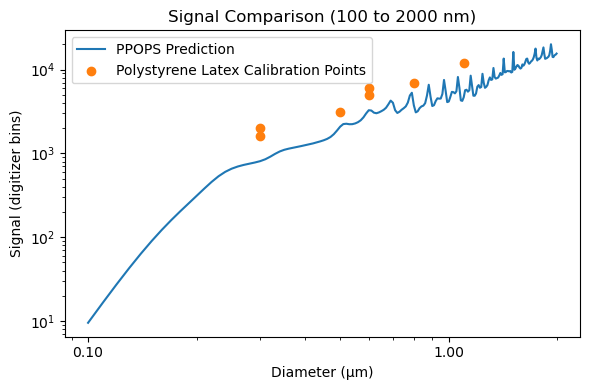

In [4]:
### Figure 1: Comparison of PPOPS Predictions to Calibration Points ###
signal, noise = ops.estimate_signal_noise(ior=psl_ri, diameters=diameters)
digitized_signal = ppops.digitize_signal(signal)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(diameters, digitized_signal, label="PPOPS Prediction", color="tab:blue")
ax.scatter(
    cal_df["Diameter (nm)"] / 1000,
    cal_df["Signal (arb.)"],
    color="tab:orange",
    label="Polystyrene Latex Calibration Points",
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Diameter (µm)")
ax.set_ylabel("Signal (digitizer bins)")
ax.set_title("Signal Comparison (100 to 2000 nm)")
ax.legend()
fig.tight_layout()

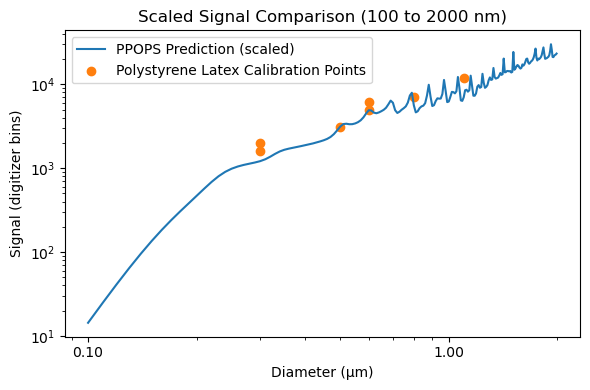

In [5]:
### Figure 2. Compare Scaled PPOPS Predictions to Calibration Points ###
# Scaling factor to better match the calibration points
signal_scaling_factor = 1.5

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    diameters,
    digitized_signal * signal_scaling_factor,
    label="PPOPS Prediction (scaled)",
    color="tab:blue",
)
ax.scatter(
    cal_df["Diameter (nm)"] / 1000,
    cal_df["Signal (arb.)"],
    color="tab:orange",
    label="Polystyrene Latex Calibration Points",
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Diameter (µm)")
ax.set_ylabel("Signal (digitizer bins)")
ax.set_title("Scaled Signal Comparison (100 to 2000 nm)")
ax.legend()
fig.tight_layout()

# Noise Comparison

PPOPS estimates shot noise but it does not estimate noise from stray
light which is likely the main source of noise. Thus, we rely on actual
instrument data to calculate a scaling factor. Unfortunately, since POPS
only records peak heights, we are limited to a figure from Gao et. al.,
Aerosol Sci. Technol., 2016 where we visually estimate the noise range
to be 20 digitizer bins for a 140 nm DOS particle. The resulting scaling
term is 19x.

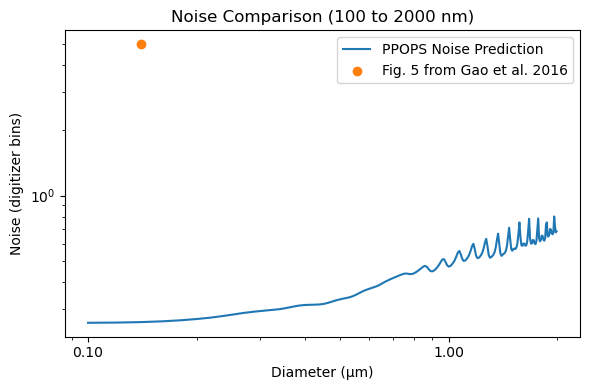

In [6]:
### Figure 3: Comparison of PPOPS Noise Predictions to Gao et al., Aerosol Sci. Technol., 2016 Figure 5 ###
# Calculate the standard deviation of the noise from Gao et al., Aerosol Sci. Technol., 2016 Figure 5
dos_noise_SD = 20 / 4

signal, noise = ops.estimate_signal_noise(ior=dos_ri, diameters=diameters)
digitized_noise = ppops.digitize_signal(noise)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(diameters, digitized_noise, label="PPOPS Noise Prediction")
ax.scatter(0.140, dos_noise_SD, color="tab:orange", label="Fig. 5 from Gao et al. 2016")
ax.set_yscale("log")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Diameter (µm)")
ax.set_ylabel("Noise (digitizer bins)")
ax.set_title("Noise Comparison (100 to 2000 nm)")
ax.legend()
fig.tight_layout()

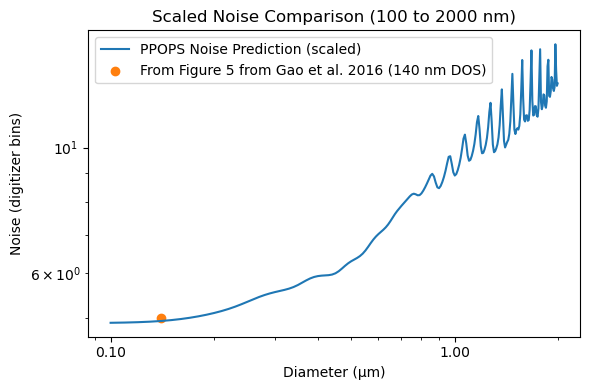

In [7]:
### Figure 4: Comparison of Scaled PPOPS Noise Predictions to Gao et al., Aerosol Sci. Technol., 2016 Figure 5 ###
signal, noise = ops.estimate_signal_noise(ior=dos_ri, diameters=diameters)
digitized_noise = ppops.digitize_signal(noise)

# Scaling factor to better match the point from Gao et al., Aerosol Sci. Technol., 2016
noise_scaling_factor = 19

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    diameters,
    digitized_noise * noise_scaling_factor,
    label="PPOPS Noise Prediction (scaled)",
)
ax.scatter(
    0.140,
    dos_noise_SD,
    color="tab:orange",
    label="From Figure 5 from Gao et al. 2016 (140 nm DOS)",
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Diameter (µm)")
ax.set_ylabel("Noise (digitizer bins)")
ax.set_title("Scaled Noise Comparison (100 to 2000 nm)")
ax.legend()
fig.tight_layout()